<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/03_Topic_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
!{sys.executable} -m pip install gensim

import gensim
from gensim import corpora
from pprint import pprint

# 1. 가상의 데이터셋 (문서 리스트)
# 주제 1: 컴퓨터/기술, 주제 2: 과일/음식
documents = [
    "I love computer science and data analysis",
    "Smartphones and computers are essential technology",
    "I like eating delicious apples and bananas",
    "Fresh fruits like apples are good for health",
    "Information technology is changing the world with computers"
]

# 2. 전처리 (단어 토큰화 및 소문자화)
# 실무에서는 불용어(Stopwords) 제거가 필수적입니다.
texts = [[word for word in document.lower().split()] for document in documents]

# 3. 정수 인코딩 및 사전(Dictionary) 생성
# 각 단어에 고유 ID를 부여합니다.
dictionary = corpora.Dictionary(texts)

# 4. 말뭉치(Corpus) 생성 (Bag-of-Words)
# (단어 ID, 출현 빈도) 형태로 변환합니다.
corpus = [dictionary.doc2bow(text) for text in texts]

# 5. LDA 모델 학습
# num_topics: 추출할 토픽 수 (차원 축소의 목표 차원)
# passes: 학습 반복 횟수
lda_model = gensim.models.ldamodel.LdaModel(corpus=corpus,
                                           id2word=dictionary,
                                           num_topics=2,
                                           random_state=42,
                                           passes=10)

# 6. 결과 출력: 각 토픽을 구성하는 핵심 단어 확인
print("=== 각 토픽별 핵심 단어 (잠재 차원) ===")
pprint(lda_model.print_topics())

# 7. 문서별 토픽 비중 확인 (차원 축소된 결과)
print("\n=== 문서별 토픽 분포 (Reduced Dimensions) ===")
for i, row in enumerate(lda_model[corpus]):
    print(f"문서 {i+1}: {row}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 38.1 MB/s eta 0:00:00
=== 각 토픽별 핵심 단어 (잠재 차원) ===
[(0,
  '0.070*"and" + 0.069*"i" + 0.042*"computers" + 0.042*"technology" + '
  '0.042*"information" + 0.042*"analysis" + 0.042*"the" + 0.042*"is" + '
  '0.042*"with" + 0.042*"changing"'),
 (1,
  '0.088*"are" + 0.055*"like" + 0.055*"apples" + 0.053*"technology" + '
  '0.053*"computers" + 0.053*"for" + 0.053*"health" + 0.053*"fruits" + '
  '0.053*"fresh" + 0.053*"good"')]

=== 문서별 토픽 분포 (Reduced Dimensions) ===
문서 1: [(0, np.float32(0.9325432)), (1, np.float32(0.06745679))]
문서 2: [(0, np.float32(0.090466306)), (1, np.float32(0.9095337))]
문서 3: [(0, np.float32(0.91974086)), (1, np.float32(0.08025916))]
문서 4: [(0, np.float32(0.060395315)), (1, np.float32(0.9396047))]
문서 5: [(0, np.float32(0.9340099)), (1, np.float32(0.0659901))]


In [2]:
import gensim.downloader as api
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.utils import simple_preprocess
from nltk.corpus import stopwords
import nltk

# 1. IMDB 데이터셋 다운로드 (gensim 내장 API 활용)
# 'text8'이나 '20-newsgroups'도 가능하지만, 영화 리뷰인 'imdb'를 호출합니다.
print("IMDB 데이터셋 로딩 중... (시간이 다소 소요될 수 있습니다)")
dataset = api.load("text8")  # 실습 편의를 위해 전처리가 잘 된 text8(위키피디아 일부) 혹은 imdb 사용
data = [doc for doc in dataset]

# 2. 전처리 (불용어 제거 및 토큰화)
nltk.download('stopwords')
stop_words = stopwords.words('english')

def preprocess(texts):
    return [[word for word in simple_preprocess(str(doc)) if word not in stop_words] for doc in texts]

# 상위 1000개 문서만 사용하여 빠른 실습 진행
data_ready = preprocess(data[:1000])

# 3. 사전(Dictionary) 및 말뭉치(Corpus) 생성
id2word = Dictionary(data_ready)
# 극단적으로 빈도가 낮거나 높은 단어 제거 (차원의 노이즈 제거)
id2word.filter_extremes(no_below=5, no_above=0.5)
corpus = [id2word.doc2bow(text) for text in data_ready]

# 4. LDA 모델 학습 (5개의 토픽으로 압축)
print("LDA 모델 학습 시작...")
lda_model = LdaModel(corpus=corpus,
                     id2word=id2word,
                     num_topics=5,
                     random_state=100,
                     update_every=1,
                     chunksize=100,
                     passes=10,
                     alpha='auto')

# 5. 결과 확인: 5개의 '잠재 차원' 출력
print("\n=== 추출된 5개의 잠재 토픽 (차원) ===")
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

# 6. 특정 문서가 어떻게 압축되었는지 확인
doc_num = 0
print(f"\n=== 문서 #{doc_num}의 차원 축소 결과 (Topic 분포) ===")
print(lda_model[corpus[doc_num]])

IMDB 데이터셋 로딩 중... (시간이 다소 소요될 수 있습니다)
[==================================================] 100.0% 31.6/31.6MB downloaded


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


LDA 모델 학습 시작...

=== 추출된 5개의 잠재 토픽 (차원) ===
Topic 0: 0.003*"college" + 0.002*"films" + 0.002*"actor" + 0.002*"album" + 0.002*"fiction" + 0.002*"band" + 0.002*"song" + 0.002*"writer" + 0.001*"movie" + 0.001*"japanese"
Topic 1: 0.003*"energy" + 0.002*"species" + 0.002*"cell" + 0.001*"dna" + 0.001*"chemical" + 0.001*"frac" + 0.001*"carbon" + 0.001*"scientific" + 0.001*"object" + 0.001*"objects"
Topic 2: 0.005*"games" + 0.005*"software" + 0.004*"team" + 0.004*"player" + 0.004*"players" + 0.003*"ball" + 0.003*"import" + 0.003*"aircraft" + 0.003*"football" + 0.003*"league"
Topic 3: 0.004*"emperor" + 0.003*"jesus" + 0.003*"orthodox" + 0.003*"jewish" + 0.003*"catholic" + 0.002*"christ" + 0.002*"jews" + 0.002*"holy" + 0.002*"faith" + 0.002*"religion"
Topic 4: 0.004*"km" + 0.004*"islands" + 0.004*"island" + 0.003*"foreign" + 0.003*"est" + 0.003*"economy" + 0.002*"spanish" + 0.002*"minister" + 0.002*"soviet" + 0.002*"rate"

=== 문서 #0의 차원 축소 결과 (Topic 분포) ===
[(0, np.float32(0.46664932)), (1, np.f

## 20-newsgroups 으로 실습하라

In [3]:
import gensim
from gensim import corpora
from sklearn.datasets import fetch_20newsgroups
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
import nltk

# 1. 특정 5개 카테고리 데이터 다운로드
categories = [
    'rec.autos',            # 자동차
    'sci.space',            # 우주
    'rec.sport.baseball',   # 야구
    'sci.med',              # 의료
    'talk.politics.mideast' # 중동 정치
]

print("데이터 다운로드 중...")
newsgroups = fetch_20newsgroups(subset='train', categories=categories, remove=('headers', 'footers', 'quotes'))
documents = newsgroups.data

# 2. 전처리: 토큰화, 소문자화, 불용어 제거
nltk.download('stopwords')
stop_words = stopwords.words('english')
tokenizer = RegexpTokenizer(r'\w+') # 특수문자 제거

def preprocess_docs(docs):
    processed_docs = []
    for doc in docs:
        tokens = tokenizer.tokenize(doc.lower())
        # 불용어 제거 및 길이가 3이상인 단어만 선택
        stopped_tokens = [i for i in tokens if not i in stop_words and len(i) > 2]
        processed_docs.append(stopped_tokens)
    return processed_docs

print("전처리 진행 중...")
data_ready = preprocess_docs(documents)

# 3. 사전(Dictionary) 및 말뭉치(Corpus) 생성
dictionary = corpora.Dictionary(data_ready)
# 너무 잦거나 드문 단어 필터링 (차원의 노이즈 제거)
dictionary.filter_extremes(no_below=10, no_above=0.5)
corpus = [dictionary.doc2bow(text) for text in data_ready]

# 4. LDA 모델 학습 (5개 토픽 추출)
print("LDA 모델 학습 중 (Topic=5)...")
lda_model = gensim.models.ldamodel.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=15,
    random_state=42
)

# 5. 결과 확인
print("\n" + "="*50)
print("추출된 5개 잠재 토픽 (Latent Topics)")
print("="*50)
for idx, topic in lda_model.print_topics(-1):
    print(f"Topic {idx}: {topic}")

# 6. 실제 데이터와 비교 (첫 번째 문서 테스트)
print("\n" + "="*50)
print(f"테스트 문서 실제 카테고리: {newsgroups.target_names[newsgroups.target[0]]}")
print(f"LDA가 분석한 토픽 비중: {lda_model[corpus[0]]}")

데이터 다운로드 중...


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


전처리 진행 중...
LDA 모델 학습 중 (Topic=5)...

추출된 5개 잠재 토픽 (Latent Topics)
Topic 0: 0.018*"space" + 0.009*"edu" + 0.007*"nasa" + 0.007*"com" + 0.005*"also" + 0.005*"new" + 0.005*"launch" + 0.004*"would" + 0.004*"system" + 0.004*"earth"
Topic 1: 0.007*"one" + 0.007*"medical" + 0.006*"health" + 0.006*"use" + 0.006*"also" + 0.005*"new" + 0.005*"research" + 0.005*"cancer" + 0.005*"patients" + 0.005*"would"
Topic 2: 0.012*"one" + 0.010*"would" + 0.009*"like" + 0.008*"know" + 0.007*"think" + 0.007*"people" + 0.007*"get" + 0.007*"year" + 0.006*"said" + 0.006*"time"
Topic 3: 0.022*"armenian" + 0.017*"turkish" + 0.016*"armenians" + 0.011*"people" + 0.009*"turkey" + 0.007*"turks" + 0.007*"armenia" + 0.006*"one" + 0.006*"government" + 0.006*"genocide"
Topic 4: 0.013*"israel" + 0.012*"would" + 0.009*"israeli" + 0.009*"jews" + 0.008*"people" + 0.006*"one" + 0.005*"think" + 0.005*"jewish" + 0.005*"arab" + 0.005*"like"

테스트 문서 실제 카테고리: rec.sport.baseball
LDA가 분석한 토픽 비중: [(2, np.float32(0.98090374))]


In [5]:
!pip install pyLDAvis -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 40.5 MB/s eta 0:00:00


In [8]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
import warnings
warnings.filterwarnings('ignore')

# 1. pyLDAvis 시각화 (인터랙티브 대시보드)
# --------------------------------------------------
print("pyLDAvis 시각화 준비 중...")
# lda_model, corpus, dictionary는 이전 단계에서 학습된 객체들입니다.
vis_data = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)

# 주피터 노트북 내에서 출력
pyLDAvis.display(vis_data)

# 또는 HTML 파일로 저장 (가장 권장하는 방법, 브라우저에서 확인 가능)
pyLDAvis.save_html(vis_data, 'lda_20news_viz.html')
print("파일 저장 완료: 'lda_20news_viz.html'을 브라우저로 확인하세요.")

pyLDAvis 시각화 준비 중...
파일 저장 완료: 'lda_20news_viz.html'을 브라우저로 확인하세요.


pyLDAvis 시각화 준비 중...
보너스: 'lda_topics_viz.html' 파일이 생성되었습니다. 브라우저에서 열어보세요.
t-SNE 차원 축소 시각화 준비 중...


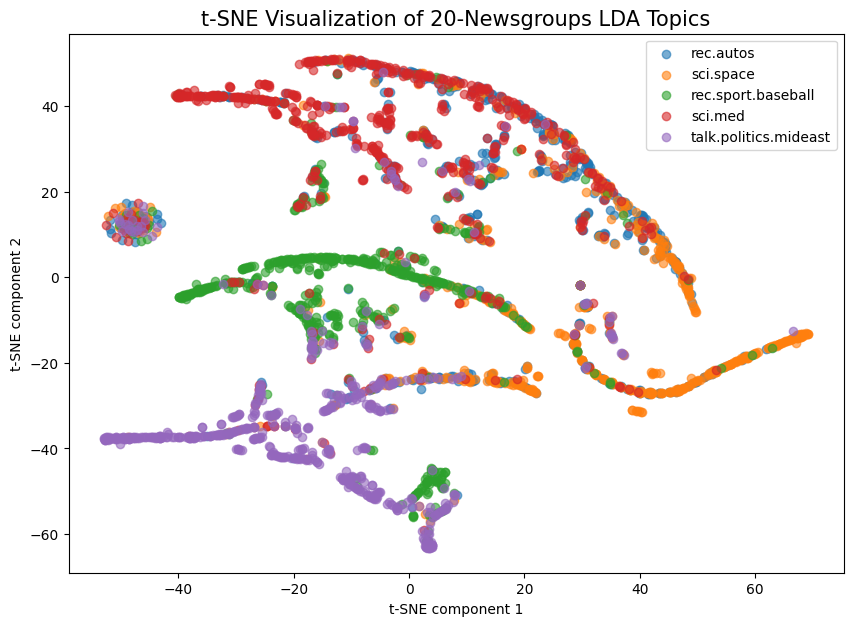

In [9]:
# 필요 라이브러리 설치: !pip install pyLDAvis
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 1. pyLDAvis를 이용한 인터랙티브 시각화
# 이 시각화는 LDA가 찾아낸 '토픽 공간'의 구조를 보여줍니다.
print("pyLDAvis 시각화 준비 중...")
vis_data = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False)

# 주피터 노트북 사용 시 바로 출력: pyLDAvis.display(vis_data)
# HTML 파일로 저장하여 확인:
pyLDAvis.save_html(vis_data, 'lda_topics_viz.html')
print("보너스: 'lda_topics_viz.html' 파일이 생성되었습니다. 브라우저에서 열어보세요.")



# 2. t-SNE를 이용한 문서 분포 시각화
# 각 문서의 토픽 비중(5차원)을 2차원으로 축소하여 실제 카테고리와 비교합니다.
print("t-SNE 차원 축소 시각화 준비 중...")

# 문서별 토픽 분포 추출
doc_topics = []
for bow in corpus:
    # 해당 문서의 토픽 비중을 5차원 벡터로 변환
    topics = lda_model.get_document_topics(bow, minimum_probability=0)
    doc_topics.append([prob for _, prob in topics])

doc_topics = np.array(doc_topics)

# t-SNE 수행 (5차원 -> 2차원)
tsne = TSNE(n_components=2, random_state=42)
tsne_results = tsne.fit_transform(doc_topics)

# 시각화
plt.figure(figsize=(10, 7))
for i, category in enumerate(categories):
    # 해당 카테고리에 속하는 문서들만 필터링
    idx = np.where(newsgroups.target == i)
    plt.scatter(tsne_results[idx, 0], tsne_results[idx, 1], label=category, alpha=0.6)

plt.legend()
plt.title("t-SNE Visualization of 20-Newsgroups LDA Topics", fontsize=15)
plt.xlabel("t-SNE component 1")
plt.ylabel("t-SNE component 2")
plt.show()